# Notebook 03 — Support Vector Machines
**DSC 240 · Machine Learning · UCSD**

The Perceptron finds *a* separating hyperplane. SVMs find the *best* one — the **maximum-margin** separator.

In this notebook:
1. Hard-margin SVM via quadratic programming
2. The margin and why it matters for generalization
3. Soft-margin SVM for non-separable data
4. The hinge loss formulation
5. Comparing loss functions

Reference: Vapnik et al. (1992 –)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_classification, make_blobs
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'pos': '#E63946', 'neg': '#457B9D', 'sv': '#F4A261', 'margin': '#2D6A4F', 'boundary': '#1d3d2f'}

## 1. The Hard-Margin SVM

**Primal problem:**
$$\min_{w, b} \frac{1}{2}\|w\|^2 \quad \text{s.t.} \quad y_i(\langle w, x_i \rangle + b) \geq 1 \quad \forall i$$

The **margin** is $\frac{2}{\|w\|}$. Minimizing $\|w\|^2$ maximizes the margin.  
This is a convex quadratic program — solvable exactly and efficiently.

Points on the margin boundary ($y_i(\langle w, x_i\rangle + b) = 1$) are **support vectors** — they define the solution.

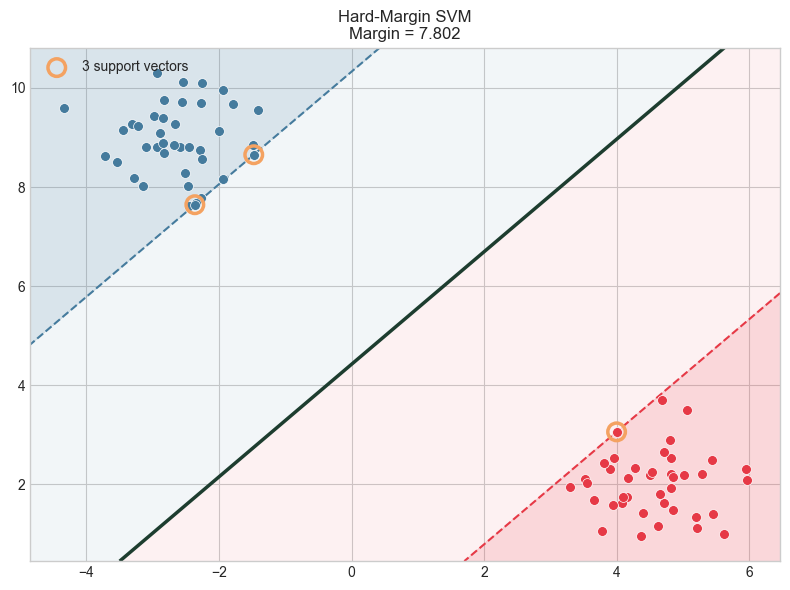

Margin: 7.8022
Support vectors: [2 1] (one per class minimum)


In [2]:
def plot_svm(ax, clf, X, y, title=''):
    """Visualize SVM decision boundary, margins, and support vectors."""
    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
    
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, levels=[-1000, -1, 0, 1, 1000],
                colors=[COLORS['neg']+'33', COLORS['neg']+'11', COLORS['pos']+'11', COLORS['pos']+'33'])
    ax.contour(xx, yy, Z, levels=[-1, 0, 1],
               colors=[COLORS['neg'], COLORS['boundary'], COLORS['pos']],
               linewidths=[1.5, 2.5, 1.5],
               linestyles=['--', '-', '--'])
    
    ax.scatter(X[y==1, 0], X[y==1, 1], c=COLORS['pos'], s=50, edgecolors='white', lw=0.5, zorder=3)
    ax.scatter(X[y==-1, 0], X[y==-1, 1], c=COLORS['neg'], s=50, edgecolors='white', lw=0.5, zorder=3)
    
    # Support vectors
    sv = clf.support_vectors_
    ax.scatter(sv[:,0], sv[:,1], s=160, facecolors='none',
               edgecolors=COLORS['sv'], linewidths=2.5, zorder=4, label=f'{len(sv)} support vectors')
    
    margin = 2 / np.linalg.norm(clf.coef_[0])
    ax.set_title(f'{title}\nMargin = {margin:.3f}', fontsize=12)
    ax.legend(fontsize=10, loc='upper left')
    ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)

# Generate well-separated data
X_sep, y_sep = make_blobs(n_samples=80, centers=2, cluster_std=0.7, random_state=42)
y_sep = 2*y_sep - 1  # convert to {±1}

clf_hard = SVC(kernel='linear', C=1e6)
clf_hard.fit(X_sep, y_sep)

fig, ax = plt.subplots(figsize=(8, 6))
plot_svm(ax, clf_hard, X_sep, y_sep, 'Hard-Margin SVM')
plt.tight_layout()
plt.savefig('../assets/figures/svm_hard_margin.png', dpi=120)
plt.show()
print(f'Margin: {2/np.linalg.norm(clf_hard.coef_[0]):.4f}')
print(f'Support vectors: {clf_hard.n_support_} (one per class minimum)')

## 2. Soft-Margin SVM — Non-Separable Data

When classes overlap, we introduce **slack variables** $\xi_i \geq 0$:

$$\min_{w, b, \xi} \frac{1}{2}\|w\|^2 + C\sum_i \xi_i \quad \text{s.t.} \quad y_i(\langle w, x_i\rangle + b) \geq 1 - \xi_i, \quad \xi_i \geq 0$$

$\xi_i$ measures how far point $i$ is on the wrong side of its margin.

**C is the key tradeoff parameter:**
- Large C: penalize violations heavily → small margin, fits training data closely
- Small C: allow more violations → large margin, more regularized

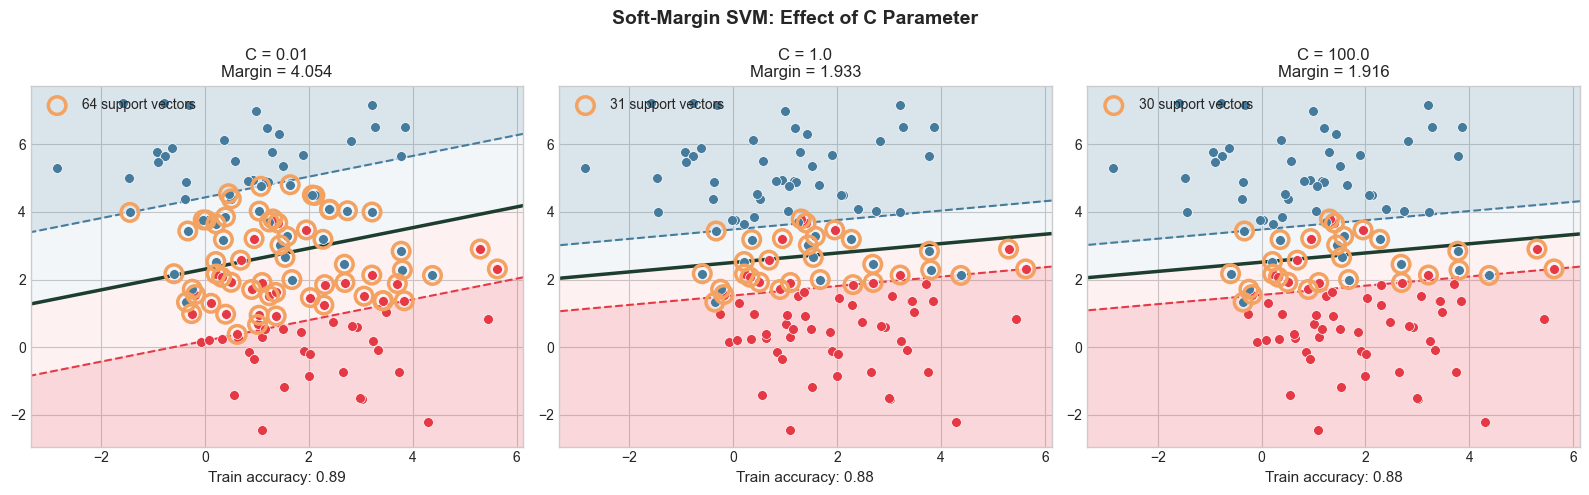

In [3]:
# Non-separable data
X_ns, y_ns = make_blobs(n_samples=120, centers=2, cluster_std=1.5, random_state=0)
y_ns = 2*y_ns - 1

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, C in zip(axes, [0.01, 1.0, 100.0]):
    clf_soft = SVC(kernel='linear', C=C)
    clf_soft.fit(X_ns, y_ns)
    plot_svm(ax, clf_soft, X_ns, y_ns, f'C = {C}')
    train_acc = clf_soft.score(X_ns, y_ns)
    ax.set_xlabel(f'Train accuracy: {train_acc:.2f}', fontsize=11)

fig.suptitle('Soft-Margin SVM: Effect of C Parameter', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/figures/svm_soft_margin.png', dpi=120)
plt.show()

## 3. Hinge Loss = Soft-Margin SVM

The soft-margin SVM is equivalent to minimizing **regularized hinge loss**:

$$\frac{1}{2}\|w\|^2 + C \sum_i \max(0, 1 - y_i f(x_i))$$

where $f(x) = \langle w, x \rangle + b$.

This shows the SVM as an instance of **Empirical Risk Minimization** with hinge loss + L2 regularization.

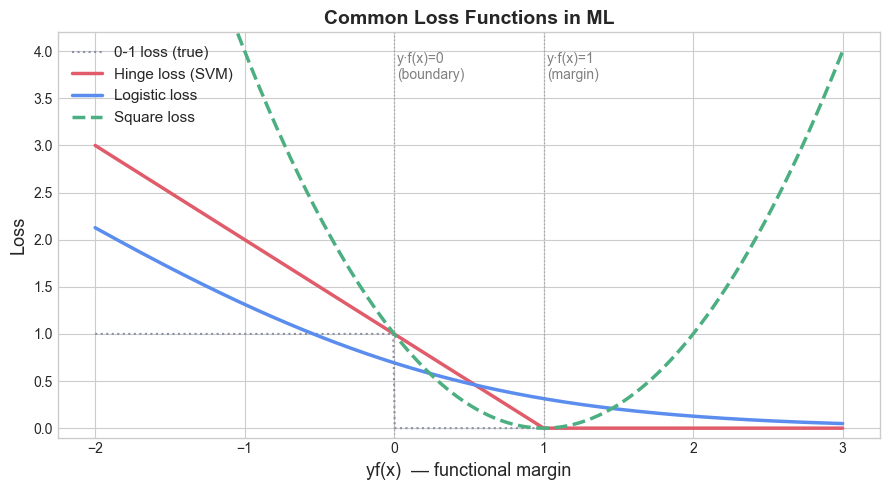

In [4]:
# Visualize and compare common loss functions
t = np.linspace(-2, 3, 500)  # yf(x)

losses = {
    '0-1 loss (true)': np.where(t < 0, 1.0, 0.0),
    'Hinge loss (SVM)': np.maximum(0, 1 - t),
    'Logistic loss': np.log1p(np.exp(-t)),
    'Square loss': (1 - t)**2,
}

colors_loss = ['#8b90a8', '#e05c6b', '#5b8dee', '#4caf81']
styles = [':', '-', '-', '--']

fig, ax = plt.subplots(figsize=(9, 5))
for (name, loss), color, style in zip(losses.items(), colors_loss, styles):
    lw = 1.5 if name.startswith('0-1') else 2.5
    ax.plot(t, loss, style, color=color, lw=lw, label=name)

ax.axvline(0, color='gray', lw=1, alpha=0.5, ls=':')
ax.axvline(1, color='gray', lw=1, alpha=0.5, ls=':')
ax.text(0.02, 3.7, 'y·f(x)=0\n(boundary)', ha='left', color='gray', fontsize=10)
ax.text(1.02, 3.7, 'y·f(x)=1\n(margin)', ha='left', color='gray', fontsize=10)

ax.set_xlabel('yf(x)  — functional margin', fontsize=13)
ax.set_ylabel('Loss', fontsize=13)
ax.set_title('Common Loss Functions in ML', fontsize=14, fontweight='bold')
ax.set_ylim(-0.1, 4.2)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../assets/figures/loss_functions.png', dpi=120)
plt.show()

## 4. Margin and Generalization

The margin connects to generalization: the **margin-dependent bound** says

$$L(c) \leq \hat{L}_{\gamma}(c) + O\left(\frac{\|w\|^2}{\gamma^2 n}\right)$$

where $\hat{L}_{\gamma}$ is the empirical margin loss. **Maximizing the margin ↔ minimizing the complexity penalty ↔ better generalization.**

This is why the SVM's objective makes statistical sense: it's not just fitting data, it's controlling the generalization gap.

## Summary

| | Perceptron | Hard-SVM | Soft-SVM |
|--|-----------|---------|--------|
| Finds | *a* separator | *best* separator | best separator w/ slack |
| Objective | None | min ‖w‖² | min ½‖w‖²+CΣξᵢ |
| Non-separable | Diverges | Infeasible | ✓ works |
| Algorithm | Online update | Quadratic program | QP / SGD |
| Key parameter | — | (none) | C (margin vs. fit) |

**Next:** How do we know *any* of these generalizes? → `04_erm_generalization.ipynb`